# Experimento neural — AND bipolar
**Marco M6 · RF28–RF33 · versão 1.0.0**

Este notebook implementa manualmente Perceptron e Adaline. O código importa somente a biblioteca padrão do Python, NumPy e Matplotlib. Pode executar em uma pasta independente, sem iniciar o laboratório.

Execute as células em ordem. Os pesos, históricos, gráficos e a comparação são produzidos pela execução. A última célula abre **um laço de predição para os dois modelos**: cada par de entradas exibe Perceptron e Adaline; digite `sair` em qualquer entrada para encerrar.

Na futura integração, \(x_1\) é solicitação de atendimento e \(x_2\) é admissibilidade. A saída representa **elegibilidade**, nunca probabilidade. A autoridade do estado, conflitos, prioridades e validação de segurança permanece no motor Python.


In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

VERSAO_EXPERIMENTO = "1.0.0"
ETA = 0.1
MAX_EPOCAS = 100
TOLERANCIA_SSE = 1e-6
PESOS_INICIAIS = np.zeros(3, dtype=np.float64)

# json, sys e pathlib pertencem à biblioteca padrão; as únicas
# dependências externas do experimento são NumPy e Matplotlib.
# Funciona ao abrir pela raiz do projeto ou pela pasta do notebook.
RAIZ_PROJETO = Path.cwd().resolve()
if RAIZ_PROJETO.name == "experimento_neural":
    RAIZ_PROJETO = RAIZ_PROJETO.parent
DIRETORIO = RAIZ_PROJETO / "experimento_neural"
if not DIRETORIO.is_dir():
    DIRETORIO = RAIZ_PROJETO  # execução independente, inclusive nos testes
ARTEFATOS = DIRETORIO / "artefatos"
ARTEFATOS.mkdir(parents=True, exist_ok=True)
ARQUIVO_PESOS = RAIZ_PROJETO / "pesos_neurais.json"

print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | Matplotlib {matplotlib.__version__}")
print(f"η = {ETA}; máximo = {MAX_EPOCAS} épocas; tolerância SSE = {TOLERANCIA_SSE:g}")
print("Inicialização: todos os pesos em zeros [w0, w1, w2] = [0, 0, 0], independentes por modelo; x0 = 1.")


Python 3.12.3 | NumPy 2.2.6 | Matplotlib 3.10.3
η = 0.1; máximo = 100 épocas; tolerância SSE = 1e-06
Inicialização: todos os pesos em zeros [w0, w1, w2] = [0, 0, 0], independentes por modelo; x0 = 1.


## Base obrigatória e convenções

| \(x_1\) | \(x_2\) | Desejado \(d\) |
| --- | --- | --- |
| 0 | 0 | −1 |
| 0 | 1 | −1 |
| 1 | 0 | −1 |
| 1 | 1 | +1 |

A ordem das amostras é fixa e não há sorteio ou embaralhamento.
Usamos \(\mathbf{x}=[1,x_1,x_2]\), \(\mathbf{w}=[w_0,w_1,w_2]\) e \(u=\mathbf{w}\cdot\mathbf{x}\).
O peso \(w_0\) é o bias e também participa de toda atualização:

\[
y = \begin{cases}+1,&u\geq0\\-1,&u<0.\end{cases}
\]

Não usamos `np.sign`, pois em zero essa função retornaria 0, fora da convenção bipolar exigida.


In [2]:
ENTRADAS = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float64)
X = np.column_stack((np.ones(len(ENTRADAS)), ENTRADAS))
D = np.array([-1, -1, -1, 1], dtype=np.int64)

def sinal(u):
    return 1 if u >= 0 else -1

assert X.shape == (4, 3)
assert np.array_equal(X[:, 0], np.ones(4))
assert sinal(0.0) == 1
print("x = [bias, x1, x2] -> d")
for x, desejado in zip(X, D):
    print(f"{x.astype(int).tolist()} -> {int(desejado):+d}")


x = [bias, x1, x2] -> d
[1, 0, 0] -> -1
[1, 0, 1] -> -1
[1, 1, 0] -> -1
[1, 1, 1] -> +1


## Perceptron — RF29

Em cada amostra: (1) calcular \(u\); (2) aplicar o sinal para obter \(y\);
(3) calcular \(d-y\); (4) atualizar **os três pesos**:

\[
\mathbf{w}\leftarrow\mathbf{w}+0{,}1(d-y)\mathbf{x}.
\]

Os erros da época são as classificações incorretas **no momento em que cada amostra é visitada**, antes da atualização correspondente. Uma época inteira com zero erros encerra o treino; o limite é 100. Os pesos começam em uma cópia independente de \([0,0,0]\).


In [3]:
def treinar_perceptron():
    w = PESOS_INICIAIS.copy()
    historico = []
    primeira_epoca = []
    motivo = "limite_epocas"

    for epoca in range(1, MAX_EPOCAS + 1):
        erros = 0
        for indice, (x, desejado) in enumerate(zip(X, D), start=1):
            antes = w.copy()
            u = float(np.dot(w, x))
            y = sinal(u)
            erro = int(desejado) - y
            if y != desejado:
                erros += 1
            w = w + ETA * erro * x

            if epoca == 1:
                primeira_epoca.append({
                    "amostra": indice, "x": x.tolist(), "d": int(desejado),
                    "u": u, "y": y, "erro": erro,
                    "pesos_antes": antes.tolist(), "pesos_depois": w.tolist(),
                })

        historico.append({"epoca": epoca, "erros": erros, "pesos": w.tolist()})
        print(f"Perceptron | época {epoca:3d} | erros = {erros} | pesos = {w}")
        if erros == 0:
            motivo = "epoca_sem_erros"
            break

    return {
        "modelo": "perceptron", "pesos": w.copy(), "historico": historico,
        "epocas": len(historico), "motivo_parada": motivo,
        "primeira_epoca": primeira_epoca,
    }

perceptron = treinar_perceptron()
print("Parada:", perceptron["motivo_parada"])


Perceptron | época   1 | erros = 2 | pesos = [0.  0.2 0.2]
Perceptron | época   2 | erros = 3 | pesos = [-0.2  0.4  0.2]
Perceptron | época   3 | erros = 3 | pesos = [-0.4  0.4  0.2]
Perceptron | época   4 | erros = 0 | pesos = [-0.4  0.4  0.2]
Parada: epoca_sem_erros


In [4]:
print("Auditoria da primeira época: pesos e erro antes de cada atualização.")
for passo in perceptron["primeira_epoca"]:
    print(f"x={passo['x']}, d={passo['d']:+d}, u={passo['u']:.6f}, "
          f"y={passo['y']:+d}, d-y={passo['erro']:+d}: "
          f"{passo['pesos_antes']} -> {passo['pesos_depois']}")


Auditoria da primeira época: pesos e erro antes de cada atualização.
x=[1.0, 0.0, 0.0], d=-1, u=0.000000, y=+1, d-y=-2: [0.0, 0.0, 0.0] -> [-0.2, 0.0, 0.0]
x=[1.0, 0.0, 1.0], d=-1, u=-0.200000, y=-1, d-y=+0: [-0.2, 0.0, 0.0] -> [-0.2, 0.0, 0.0]
x=[1.0, 1.0, 0.0], d=-1, u=-0.200000, y=-1, d-y=+0: [-0.2, 0.0, 0.0] -> [-0.2, 0.0, 0.0]
x=[1.0, 1.0, 1.0], d=+1, u=-0.200000, y=-1, d-y=+2: [-0.2, 0.0, 0.0] -> [0.0, 0.2, 0.2]


## Adaline — RF30

O Adaline começa em **outra cópia** de \([0,0,0]\), com a mesma taxa e ordem.
Para cada amostra, usa o erro da **saída linear**, sem sinal na atualização:

\[
u=\mathbf{w}\cdot\mathbf{x},\qquad
\mathbf{w}\leftarrow\mathbf{w}+0{,}1(d-u)\mathbf{x}.
\]

Depois de todas as quatro atualizações da época \(t\), recalculamos as quatro saídas com os **mesmos pesos finais daquela época**:

\[
SSE_t=\sum_{i=1}^{4}(d_i-\mathbf{w}_{t,\mathrm{final}}\cdot\mathbf{x}_i)^2.
\]

Não acumulamos resíduos calculados com pesos diferentes ao longo da época.
A partir da segunda época, paramos se \(|SSE_t-SSE_{t-1}|<10^{-6}\), ou ao atingir 100 épocas.
SSE não é contagem de erros de classificação, nem se exige SSE zero ou queda estritamente monotônica.
O sinal só será aplicado na **predição**, depois do treinamento.


In [5]:
def treinar_adaline():
    w = PESOS_INICIAIS.copy()
    historico = []
    primeira_epoca = []
    sse_anterior = None
    motivo = "limite_epocas"

    for epoca in range(1, MAX_EPOCAS + 1):
        for indice, (x, desejado) in enumerate(zip(X, D), start=1):
            antes = w.copy()
            u = float(np.dot(w, x))
            erro_linear = float(desejado) - u
            w = w + ETA * erro_linear * x  # sem sinal nesta atualização

            if epoca == 1:
                primeira_epoca.append({
                    "amostra": indice, "x": x.tolist(), "d": int(desejado),
                    "u": u, "erro_linear": erro_linear,
                    "pesos_antes": antes.tolist(), "pesos_depois": w.tolist(),
                })

        saidas_lineares = np.dot(X, w)
        sse = float(np.sum((D - saidas_lineares) ** 2))
        variacao = None if sse_anterior is None else abs(sse - sse_anterior)
        historico.append({
            "epoca": epoca, "sse": sse, "variacao_sse": variacao, "pesos": w.tolist(),
        })
        texto_variacao = "não aplicável" if variacao is None else f"{variacao:.10f}"
        print(f"Adaline | época {epoca:3d} | SSE = {sse:.10f} | ΔSSE = {texto_variacao}")

        if variacao is not None and variacao < TOLERANCIA_SSE:
            motivo = "variacao_sse_abaixo_tolerancia"
            break
        sse_anterior = sse

    return {
        "modelo": "adaline", "pesos": w.copy(), "historico": historico,
        "epocas": len(historico), "motivo_parada": motivo,
        "primeira_epoca": primeira_epoca,
    }

adaline = treinar_adaline()
assert not np.shares_memory(perceptron["pesos"], adaline["pesos"])
assert np.array_equal(PESOS_INICIAIS, np.zeros(3))
print("Parada:", adaline["motivo_parada"])


Adaline | época   1 | SSE = 3.5182823200 | ΔSSE = não aplicável
Adaline | época   2 | SSE = 3.1483534934 | ΔSSE = 0.3699288266
Adaline | época   3 | SSE = 2.8460863104 | ΔSSE = 0.3022671830
Adaline | época   4 | SSE = 2.5915706301 | ΔSSE = 0.2545156803
Adaline | época   5 | SSE = 2.3740848047 | ΔSSE = 0.2174858254
Adaline | época   6 | SSE = 2.1868829739 | ΔSSE = 0.1872018309
Adaline | época   7 | SSE = 2.0251727968 | ΔSSE = 0.1617101771
Adaline | época   8 | SSE = 1.8852515772 | ΔSSE = 0.1399212196
Adaline | época   9 | SSE = 1.7641045212 | ΔSSE = 0.1211470560
Adaline | época  10 | SSE = 1.6592010428 | ΔSSE = 0.1049034784
Adaline | época  11 | SSE = 1.5683808267 | ΔSSE = 0.0908202160
Adaline | época  12 | SSE = 1.4897827965 | ΔSSE = 0.0785980302
Adaline | época  13 | SSE = 1.4217959402 | ΔSSE = 0.0679868563
Adaline | época  14 | SSE = 1.3630222317 | ΔSSE = 0.0587737085
Adaline | época  15 | SSE = 1.3122469508 | ΔSSE = 0.0507752810
Adaline | época  16 | SSE = 1.2684140216 | ΔSSE = 0.04

In [6]:
print("Auditoria da primeira época: correções baseadas em d-u, sem classificação.")
for passo in adaline["primeira_epoca"]:
    print(f"x={passo['x']}, d={passo['d']:+d}, u={passo['u']:.6f}, "
          f"d-u={passo['erro_linear']:.6f}: "
          f"{passo['pesos_antes']} -> {passo['pesos_depois']}")


Auditoria da primeira época: correções baseadas em d-u, sem classificação.
x=[1.0, 0.0, 0.0], d=-1, u=0.000000, d-u=-1.000000: [0.0, 0.0, 0.0] -> [-0.1, 0.0, 0.0]
x=[1.0, 0.0, 1.0], d=-1, u=-0.100000, d-u=-0.900000: [-0.1, 0.0, 0.0] -> [-0.19, 0.0, -0.09000000000000001]
x=[1.0, 1.0, 0.0], d=-1, u=-0.190000, d-u=-0.810000: [-0.19, 0.0, -0.09000000000000001] -> [-0.271, -0.08100000000000002, -0.09000000000000001]
x=[1.0, 1.0, 1.0], d=+1, u=-0.442000, d-u=1.442000: [-0.271, -0.08100000000000002, -0.09000000000000001] -> [-0.1268, 0.0632, 0.05420000000000001]


## Predição e verificação exaustiva da AND

O domínio tem apenas quatro combinações, portanto podemos verificar todas.
As saídas abaixo são calculadas com os pesos treinados, sem arredondar.
Soma ponderada e saída bipolar são apresentadas separadamente; nenhuma delas é uma porcentagem de confiança.


In [7]:
def diagnosticar(pesos, x1, x2):
    if any(type(v) not in (int, np.int64) or v not in (0, 1) for v in (x1, x2)):
        raise ValueError("As entradas devem ser os inteiros binários 0 ou 1.")
    w = np.asarray(pesos, dtype=np.float64)
    if w.shape != (3,) or not np.all(np.isfinite(w)):
        raise ValueError("Informe três pesos finitos na ordem [w0, w1, w2].")
    x = np.array([1, x1, x2], dtype=np.float64)
    u = float(np.dot(w, x))
    y = sinal(u)
    referencia = 1 if x1 == 1 and x2 == 1 else -1
    return {
        "entradas": [x1, x2], "bias": 1, "pesos": w.tolist(),
        "soma_ponderada": u, "saida": y, "and_referencia": referencia,
        "elegivel": y == 1, "correto": y == referencia,
    }

resultados = (perceptron, adaline)
verificacoes = {}
for resultado in resultados:
    nome = resultado["modelo"]
    verificacoes[nome] = [
        diagnosticar(resultado["pesos"], int(x1), int(x2))
        for x1, x2 in ENTRADAS
    ]
    print(f"\n{nome.upper()}:")
    print("x1 x2 | soma ponderada u | y | AND | correto")
    for linha in verificacoes[nome]:
        x1, x2 = linha["entradas"]
        print(f" {x1}  {x2} | {linha['soma_ponderada']:+.12g} | "
              f"{linha['saida']:+d} | {linha['and_referencia']:+d} | {linha['correto']}")
    assert all(linha["correto"] for linha in verificacoes[nome]), f"{nome}: divergência da AND."



PERCEPTRON:
x1 x2 | soma ponderada u | y | AND | correto
 0  0 | -0.4 | -1 | -1 | True
 0  1 | -0.2 | -1 | -1 | True
 1  0 | -5.55111512313e-17 | -1 | -1 | True
 1  1 | +0.2 | +1 | +1 | True

ADALINE:
x1 x2 | soma ponderada u | y | AND | correto
 0  0 | -1.5539597476 | -1 | -1 | True
 0  1 | -0.499618266155 | -1 | -1 | True
 1  0 | -0.443999005871 | -1 | -1 | True
 1  1 | +0.610342475572 | +1 | +1 | True


## Curvas de aprendizado — RF32

O painel esquerdo conta erros de classificação durante cada época do Perceptron.
O direito mostra SSE ao final de cada época do Adaline. As escalas verticais são distintas e explicitamente rotuladas.
As figuras são exibidas aqui e exportadas em PNG e SVG para o relatório.


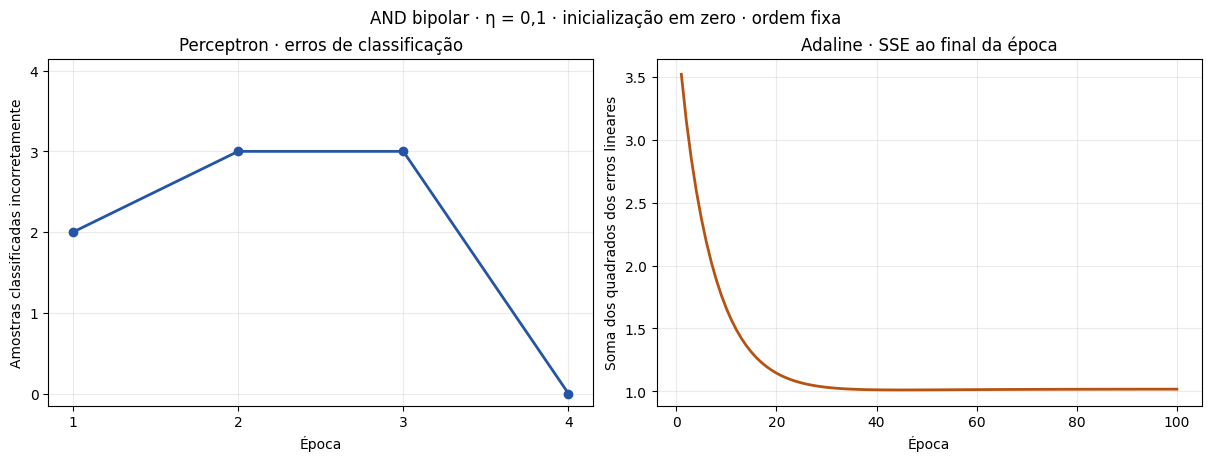

In [8]:
epocas_p = [h["epoca"] for h in perceptron["historico"]]
erros_p = [h["erros"] for h in perceptron["historico"]]
epocas_a = [h["epoca"] for h in adaline["historico"]]
sse_a = [h["sse"] for h in adaline["historico"]]

fig_curvas, eixos = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
eixos[0].plot(epocas_p, erros_p, color="#2455a4", marker="o", linewidth=2)
eixos[0].set(title="Perceptron · erros de classificação", xlabel="Época",
             ylabel="Amostras classificadas incorretamente", ylim=(-0.15, 4.15))
eixos[0].set_yticks(range(5))
eixos[0].set_xticks(epocas_p[::max(1, len(epocas_p) // 10)])
eixos[1].plot(epocas_a, sse_a, color="#b65312", linewidth=2)
eixos[1].set(title="Adaline · SSE ao final da época", xlabel="Época",
             ylabel="Soma dos quadrados dos erros lineares")
for eixo in eixos:
    eixo.grid(alpha=0.25)
fig_curvas.suptitle("AND bipolar · η = 0,1 · inicialização em zero · ordem fixa")
for extensao in ("png", "svg"):
    fig_curvas.savefig(ARTEFATOS / f"curvas_aprendizado.{extensao}", dpi=180)
plt.show()


## Pesos, épocas e retas de decisão

A fronteira é \(w_0+w_1x_1+w_2x_2=0\).
Quando \(w_2\neq0\), podemos escrever \(x_2=-(w_0+w_1x_1)/w_2\).
A região \(u\geq0\) recebe +1, inclusive a própria fronteira.
A tabela arredonda **somente a apresentação**; predições e JSON usam os valores completos.


perceptron: -0.400000 +0.400000·x1 +0.200000·x2 = 0; épocas=4; parada=epoca_sem_erros
adaline: -1.553960 +1.109961·x1 +1.054341·x2 = 0; épocas=100; parada=limite_epocas


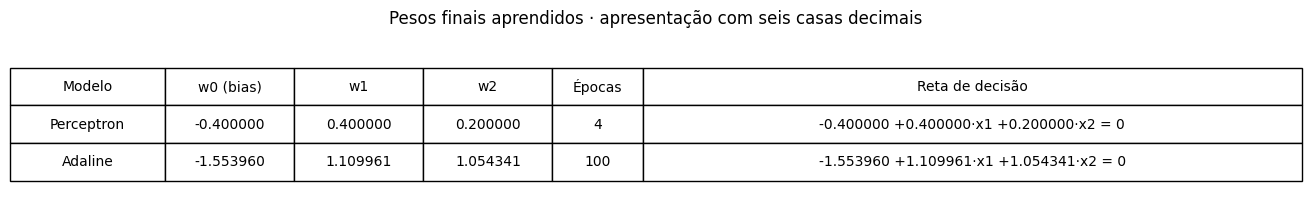

In [9]:
def equacao_reta(pesos):
    w0, w1, w2 = pesos
    return f"{w0:+.6f} {w1:+.6f}·x1 {w2:+.6f}·x2 = 0"

linhas_tabela = []
for resultado in resultados:
    w0, w1, w2 = resultado["pesos"]
    linhas_tabela.append([
        resultado["modelo"].capitalize(), f"{w0:.6f}", f"{w1:.6f}", f"{w2:.6f}",
        str(resultado["epocas"]), equacao_reta(resultado["pesos"]),
    ])
    print(f"{resultado['modelo']}: {equacao_reta(resultado['pesos'])}; "
          f"épocas={resultado['epocas']}; parada={resultado['motivo_parada']}")

fig_tabela, eixo = plt.subplots(figsize=(13, 2.1), layout="constrained")
eixo.axis("off")
tabela = eixo.table(
    cellText=linhas_tabela, colLabels=["Modelo", "w0 (bias)", "w1", "w2", "Épocas", "Reta de decisão"],
    colWidths=[.12, .10, .10, .10, .07, .51], cellLoc="center", loc="center",
)
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1, 2.1)
eixo.set_title("Pesos finais aprendidos · apresentação com seis casas decimais", pad=10)
for extensao in ("png", "svg"):
    fig_tabela.savefig(ARTEFATOS / f"tabela_pesos.{extensao}", dpi=180)
plt.show()


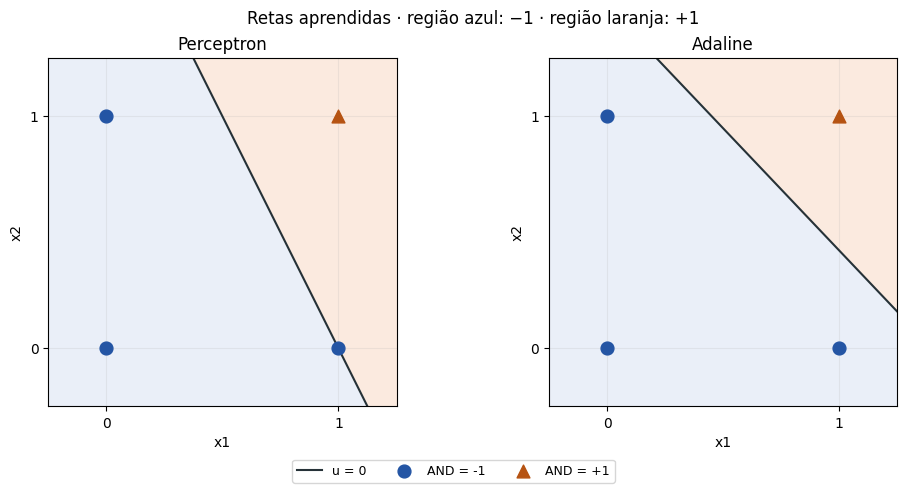

In [10]:
fig_retas, eixos = plt.subplots(1, 2, figsize=(10, 4.8), layout="constrained")
grade = np.linspace(-0.25, 1.25, 200)
xx, yy = np.meshgrid(grade, grade)

for eixo, resultado in zip(eixos, resultados):
    w0, w1, w2 = resultado["pesos"]
    u_grade = w0 + w1 * xx + w2 * yy
    eixo.contourf(xx, yy, np.where(u_grade >= 0, 1, -1),
                 levels=[-2, 0, 2], colors=["#e5ecf7", "#fbe5d7"], alpha=.8)
    if w2 != 0:
        eixo.plot(grade, -(w0 + w1 * grade) / w2, color="#263238", label="u = 0")
    elif w1 != 0:
        eixo.axvline(-w0 / w1, color="#263238", label="u = 0")
    else:
        eixo.text(.5, .5, "Sem reta: w1 = w2 = 0", ha="center")
    for desejado, cor, marcador in [(-1, "#2455a4", "o"), (1, "#b65312", "^")]:
        pontos = ENTRADAS[D == desejado]
        eixo.scatter(pontos[:, 0], pontos[:, 1], color=cor, marker=marcador,
                     s=85, zorder=3, label=f"AND = {desejado:+d}")
    eixo.set(title=resultado["modelo"].capitalize(), xlabel="x1", ylabel="x2",
             xlim=(-.25, 1.25), ylim=(-.25, 1.25), xticks=[0, 1], yticks=[0, 1])
    eixo.set_aspect("equal")
    eixo.grid(alpha=.2)
handles, labels = eixos[0].get_legend_handles_labels()
fig_retas.legend(handles, labels, loc="outside lower center", ncols=3, fontsize=9)
fig_retas.suptitle("Retas aprendidas · região azul: −1 · região laranja: +1")
for extensao in ("png", "svg"):
    fig_retas.savefig(ARTEFATOS / f"retas_decisao.{extensao}", dpi=180)
plt.show()


## Comparação acadêmica — por que as curvas diferem?

O Perceptron mede o erro de classificação **depois** de aplicar a função sinal à soma ponderada.  
Sua atualização usa $d-y$, enquanto o gráfico conta quantas classificações estão erradas em cada época.  
Essa contagem é inteira e muda em saltos quando uma amostra atravessa a fronteira de decisão.  
Corrigir uma amostra pode modificar a classificação de outra, causando oscilações entre épocas.  
Por isso a curva pode ser irregular, apresentar patamares ou aumentar antes de chegar a zero.  
O Adaline mede o resíduo $d-u$ na saída **linear**, antes de qualquer aplicação do sinal.  
A regra delta usa a magnitude desse resíduo para ajustar os pesos a cada amostra.  
Seu gráfico mostra $SSE=\sum_i(d_i-\mathbf{w}\cdot\mathbf{x}_i)^2$, recalculado ao final da época.  
O SSE é uma função quadrática contínua dos pesos, ao contrário da contagem discreta do Perceptron.  
Com uma taxa adequada, os ajustes graduais costumam produzir uma curva visualmente mais suave.  
Suavidade não garante queda monotônica: atualizações por amostra e taxa fixa podem elevar o SSE.  
Nesta execução, o Adaline chega a 100 épocas sem satisfazer $|\Delta SSE|<10^{-6}$, embora acerte a AND.  
SSE residual e erro de classificação são distintos; no Adaline, o sinal só entra na predição final.


In [11]:
aumentos_sse = int(np.count_nonzero(np.diff(sse_a) > 0))
delta_final = adaline["historico"][-1]["variacao_sse"]
menor_margem_p = min(abs(r["soma_ponderada"]) for r in verificacoes["perceptron"])
linhas_comparacao = [
    "Os dois modelos usaram a AND bipolar, pesos iniciais em zero, η = 0,1 e a mesma ordem fixa.",
    "O Perceptron mede erros após o sinal, no instante em que cada amostra é visitada.",
    f"Sua curva começou com {erros_p[0]} erros e terminou com {erros_p[-1]}, após {perceptron['epocas']} épocas.",
    "A contagem discreta muda em saltos; corrigir uma amostra pode prejudicar outra e tornar a curva irregular.",
    "O Adaline ajusta os pesos pelo erro linear d−u, sem aplicar sinal durante as atualizações.",
    f"O SSE passou de {sse_a[0]:.8f} para {sse_a[-1]:.8f} ao longo de {adaline['epocas']} épocas.",
    "Cada SSE foi recalculado nas quatro amostras usando os pesos finais daquela época.",
    f"Foram observados {aumentos_sse} aumentos de SSE entre épocas; o último |ΔSSE| foi {delta_final:.10f}.",
    f"O Adaline parou por '{adaline['motivo_parada']}', com tolerância de 10⁻⁶ e limite de 100 épocas.",
    "Com o sinal u ≥ 0 → +1 na predição, ambos classificaram corretamente as quatro combinações.",
    "As retas e os pesos diferem; SSE residual não significa necessariamente erro de classificação.",
    f"A menor |u| do Perceptron foi {menor_margem_p:.3e}; arredondar os pesos pode alterar a classe na fronteira.",
    "O SSE é contínuo e quadrático nos pesos: a curva tende a ser suave, sem garantia de queda monotônica no treino por amostra.",
]
assert len(linhas_comparacao) == 13
for numero, linha in enumerate(linhas_comparacao, 1):
    print(f"{numero:02d}. {linha}")
(ARTEFATOS / "comparacao.txt").write_text("\n".join(linhas_comparacao) + "\n", encoding="utf-8")


01. Os dois modelos usaram a AND bipolar, pesos iniciais em zero, η = 0,1 e a mesma ordem fixa.
02. O Perceptron mede erros após o sinal, no instante em que cada amostra é visitada.
03. Sua curva começou com 2 erros e terminou com 0, após 4 épocas.
04. A contagem discreta muda em saltos; corrigir uma amostra pode prejudicar outra e tornar a curva irregular.
05. O Adaline ajusta os pesos pelo erro linear d−u, sem aplicar sinal durante as atualizações.
06. O SSE passou de 3.51828232 para 1.01822337 ao longo de 100 épocas.
07. Cada SSE foi recalculado nas quatro amostras usando os pesos finais daquela época.
08. Foram observados 55 aumentos de SSE entre épocas; o último |ΔSSE| foi 0.0000206593.
09. O Adaline parou por 'limite_epocas', com tolerância de 10⁻⁶ e limite de 100 épocas.
10. Com o sinal u ≥ 0 → +1 na predição, ambos classificaram corretamente as quatro combinações.
11. As retas e os pesos diferem; SSE residual não significa necessariamente erro de classificação.
12. A menor |u| 

1161

## Exportação versionada e verificação da leitura — RF33

A função `salvar_pesos_neurais` grava `pesos_neurais.json` **na raiz do projeto**. O arquivo contém pesos em ordem **[w0, w1, w2]**, versão, inicialização, taxa, limites, épocas executadas, regras de atualização, motivo de parada, históricos e resultados nas quatro combinações.

O validador abaixo verifica o contrato antes do uso: versão, treinamento, dimensões e finitude dos pesos, convenção bipolar e parâmetros. Ele **recalcula** as quatro saídas, em vez de confiar em um campo `correto` gravado. Divergências são listadas e impedem a condição `apto_para_ativacao`.

Uma nova execução atualiza esse arquivo com os pesos treinados, preservando a precisão completa. O notebook entrega o artefato para importação. A seleção do avaliador no laboratório e sua ligação ao controle semafórico são uma etapa de integração; carregar pesos não concede permissões de tráfego. O motor deverá validar novamente os pesos antes de ativá-los.


In [12]:
documento = {
    "schema_version": "1.0",
    "experimento": "and_bipolar",
    "versao_experimento": VERSAO_EXPERIMENTO,
    "ordem_pesos": ["w0", "w1", "w2"],
    "entradas": {
        "ordem": ["bias", "x1", "x2"], "bias": 1, "dominio": [0, 1],
        "semantica_motor": {"x1": "solicitacao_atendimento", "x2": "admissibilidade"},
    },
    "convencao_saida": {"negativa": -1, "positiva": 1, "limiar": 0.0, "positivo_inclui_limiar": True},
    "base_treinamento": [{"x": x.tolist(), "d": int(d)} for x, d in zip(X, D)],
    "dtype_calculo": "float64",
    "ambiente": {"python": sys.version.split()[0], "numpy": np.__version__, "matplotlib": matplotlib.__version__},
    "modelos": {},
}
for resultado in resultados:
    nome = resultado["modelo"]
    documento["modelos"][nome] = {
        "modelo": nome, "versao": VERSAO_EXPERIMENTO, "treinado": True,
        "pesos": resultado["pesos"].tolist(), "inicializacao": PESOS_INICIAIS.tolist(),
        "taxa_aprendizado": ETA, "max_epocas": MAX_EPOCAS,
        "epocas_executadas": resultado["epocas"], "ordem_amostras": ENTRADAS.astype(int).tolist(),
        "regra_atualizacao": "w <- w + eta * (d - y) * x" if nome == "perceptron" else "w <- w + eta * (d - u) * x",
        "metrica_treino": "erros_classificacao_antes_da_atualizacao" if nome == "perceptron" else "sse_com_pesos_do_final_da_epoca",
        "criterio_parada": "epoca_inteira_sem_erros" if nome == "perceptron" else "abs(sse_atual - sse_anterior) < tolerancia_sse",
        "tolerancia_sse": None if nome == "perceptron" else TOLERANCIA_SSE,
        "motivo_parada": resultado["motivo_parada"],
        "historico": resultado["historico"],
        "verificacao_and": verificacoes[nome],
    }


In [13]:
def validar_documento(dados):
    if not isinstance(dados, dict) or dados.get("schema_version") != "1.0":
        raise ValueError("Versão de arquivo não suportada.")
    if dados.get("experimento") != "and_bipolar" or dados.get("versao_experimento") != VERSAO_EXPERIMENTO:
        raise ValueError("Experimento ou versão incompatível.")
    if dados.get("ordem_pesos") != ["w0", "w1", "w2"]:
        raise ValueError("Ordem dos pesos incompatível.")
    entradas_esperadas = {
        "ordem": ["bias", "x1", "x2"], "bias": 1, "dominio": [0, 1],
        "semantica_motor": {"x1": "solicitacao_atendimento", "x2": "admissibilidade"},
    }
    if dados.get("entradas") != entradas_esperadas:
        raise ValueError("Domínio, bias ou ordem das entradas incompatível.")
    if dados.get("dtype_calculo") != "float64":
        raise ValueError("Precisão de cálculo incompatível.")
    convencao = {"negativa": -1, "positiva": 1, "limiar": 0.0, "positivo_inclui_limiar": True}
    if dados.get("convencao_saida") != convencao:
        raise ValueError("Convenção de sinal incompatível.")
    modelos = dados.get("modelos")
    if not isinstance(modelos, dict) or set(modelos) != {"perceptron", "adaline"}:
        raise ValueError("O arquivo deve conter Perceptron e Adaline.")

    relatorio = {}
    for nome, modelo in modelos.items():
        if not isinstance(modelo, dict) or modelo.get("modelo") != nome or modelo.get("versao") != VERSAO_EXPERIMENTO:
            raise ValueError(f"{nome}: identificação inválida.")
        epocas = modelo.get("epocas_executadas")
        if modelo.get("treinado") is not True or type(epocas) is not int or not 1 <= epocas <= MAX_EPOCAS:
            raise ValueError(f"{nome}: modelo sem treinamento válido.")
        w = modelo.get("pesos")
        if not isinstance(w, list) or len(w) != 3 or any(
            type(v) not in (int, float) or not np.isfinite(v) for v in w
        ):
            raise ValueError(f"{nome}: pesos devem ser três números finitos.")
        if (modelo.get("inicializacao") != [0.0, 0.0, 0.0] or
                modelo.get("taxa_aprendizado") != ETA or
                type(modelo.get("max_epocas")) is not int or modelo["max_epocas"] != MAX_EPOCAS or
                modelo.get("ordem_amostras") != ENTRADAS.astype(int).tolist()):
            raise ValueError(f"{nome}: parâmetros de treinamento incompatíveis.")
        motivos = {"epoca_sem_erros", "limite_epocas"} if nome == "perceptron" else {"variacao_sse_abaixo_tolerancia", "limite_epocas"}
        if modelo.get("motivo_parada") not in motivos:
            raise ValueError(f"{nome}: motivo de parada inválido.")
        if nome == "adaline" and modelo.get("tolerancia_sse") != TOLERANCIA_SSE:
            raise ValueError("Adaline: tolerância SSE incompatível.")
        historico = modelo.get("historico")
        if not isinstance(historico, list) or len(historico) != epocas or any(
            not isinstance(h, dict) or h.get("epoca") != i
            for i, h in enumerate(historico, 1)
        ):
            raise ValueError(f"{nome}: histórico não corresponde às épocas.")
        if historico[-1].get("pesos") != w:
            raise ValueError(f"{nome}: pesos finais não correspondem ao histórico.")
        linhas = [diagnosticar(w, int(x1), int(x2)) for x1, x2 in ENTRADAS]
        divergencias = [linha for linha in linhas if not linha["correto"]]
        relatorio[nome] = {
            "apto_para_ativacao": not divergencias,
            "verificacao_and": linhas, "divergencias": divergencias,
        }
    return relatorio


def salvar_pesos_neurais(dados, caminho=ARQUIVO_PESOS):
    """Salva os dois modelos em JSON na raiz, sem arredondar seus pesos."""
    relatorio = validar_documento(dados)
    if not all(r["apto_para_ativacao"] for r in relatorio.values()):
        raise ValueError("Os pesos treinados não reproduzem todas as combinações da AND.")
    caminho = Path(caminho)
    conteudo = json.dumps(dados, ensure_ascii=False, indent=2, allow_nan=False) + "\n"
    caminho.write_text(conteudo, encoding="utf-8")
    return caminho


# Exportação antes do input(): a interação não bloqueia a geração do arquivo.
salvar_pesos_neurais(documento)
# Verifica também o round-trip em disco, sem depender dos arrays originais.
recarregado = json.loads(ARQUIVO_PESOS.read_text(encoding="utf-8"))
relatorio_leitura = validar_documento(recarregado)
assert all(r["apto_para_ativacao"] for r in relatorio_leitura.values())
print("Exportado:", ARQUIVO_PESOS)
for nome, validacao in relatorio_leitura.items():
    print(f"{nome}: apto para AND = {validacao['apto_para_ativacao']}; divergências = {validacao['divergencias']}")


Exportado: /home/derp/lab_semaforos_inteligentes/pesos_neurais.json
perceptron: apto para AND = True; divergências = []
adaline: apto para AND = True; divergências = []


## Referências e execução

As regras matemáticas, parâmetros e entregáveis seguem as Seções 11 e 12 de `requisitos.md`.
O produto escalar usa [numpy.dot](https://numpy.org/doc/stable/reference/generated/numpy.dot.html);
as figuras usam [matplotlib.pyplot.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html).
Nenhuma dessas funções implementa o treinamento dos modelos.

A validação automatizada executa as células de cálculo e exportação em kernel novo e testa o laço com entradas programadas.
Somente a última célula tem a tag `interativa`, para que a automação não fique aguardando teclado.
No Jupyter, execute-a normalmente: cada par de entradas produz as duas predições; `sair` encerra a interação.


In [14]:
def ler_binario(rotulo):
    while True:
        try:
            texto = input(f"{rotulo} [0, 1 ou sair]: ").strip().lower()
            if texto == "sair":
                return None
            valor = int(texto)
            if valor not in (0, 1):
                raise ValueError("Valor fora do domínio binário.")
            return valor
        except ValueError:
            print("Entrada inválida. Digite somente 0, 1 ou sair.")
        except (EOFError, KeyboardInterrupt):
            print("\nEntrada encerrada.")
            return None


def interagir():
    print("\nAND bipolar — Perceptron e Adaline. Digite 'sair' em qualquer entrada para encerrar.")
    while True:
        x1 = ler_binario("x1")
        if x1 is None:
            print("Laço de predição encerrado.")
            return
        x2 = ler_binario("x2")
        if x2 is None:
            print("Laço de predição encerrado.")
            return
        print(f"\nEntradas: x1={x1}, x2={x2} (bias x0=1)")
        for resultado in resultados:
            r = diagnosticar(resultado["pesos"], x1, x2)
            print(f"{resultado['modelo'].capitalize()} | u={r['soma_ponderada']:.12g} | "
                  f"y={r['saida']:+d} | AND={r['and_referencia']:+d}")


In [ ]:
# Execute esta célula para consultar ambos os modelos com os pesos treinados.
interagir()
